In [3]:
import numpy as np
from neuronal_curves import counts, draw

In [6]:
df = 0.5
rho = 1
N = 100
N_in = 50
n_f, n_b = counts(N, df, rho)

In [7]:
rng = np.random.default_rng(113)
v, F, B, theta = draw(N, N_in, 1000, n_f, n_b, rng)

In [10]:
B.shape

(1000, 100)

(5, 1, 40)
(5, 1, 40)


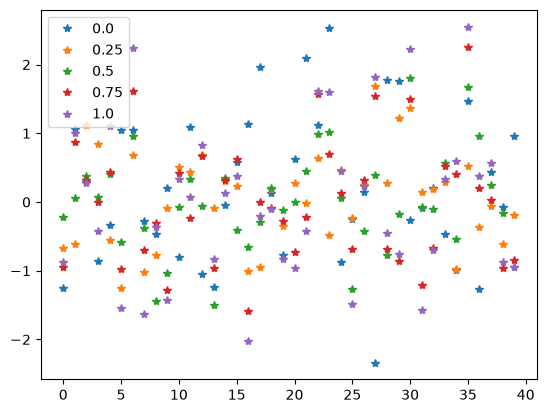

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def draw_teachers(K, N_in, kappa, rng):
    u0 = rng.standard_normal(N_in)
    u0 /= np.linalg.norm(u0)                        # shared direction
    U = rng.standard_normal((K, N_in))
    U -= np.outer(U @ u0, u0)                       # private parts orthogonal to it
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    return np.sqrt(kappa) * u0 + np.sqrt(1 - kappa) * U   # (K, N_in), unit rows

N_in = 1
N_v = 5
N_T = 40
vs = v = np.linspace(0,1.0,N_v)
v = vs[:,None,None] * np.ones((N_v,N_in,N_T))
print(v.shape)
theta_0 = np.random.randn(N_in,N_T)/np.sqrt(N_in)
theta_tilde_ts = np.random.randn(N_v,N_in,N_T)/np.sqrt(N_in)
theta_ts = v*theta_0[None,:,:] + np.sqrt((1-v)**2) * theta_tilde_ts
print(theta_ts.shape)
# theta_ts = theta_ts/np.linalg.norm(theta_ts, axis=1)[:,None,:]
for i in range(N_v):  
    if N_in == 1:
        plt.plot(range(N_T),theta_ts[i,0,:],marker='*',linestyle='none',label=f'{vs[i]}')
    else:
        plt.plot(theta_ts[i,0,:],theta_ts[i,1,:],marker='*',linestyle='none',label=f'{vs[i]}')
plt.legend()


In [4]:
plt.close()

In [ ]:
a = np.eye(5)
u,s,v = np.linalg.svd(a)
print(s)